In [1]:
import pandas as pd   

train=pd.read_csv("/Users/withmocha/Desktop/DATA/SW DACON(24)/Data/main/train/0712/train data columns.csv",index_col=0)

train

,0,1,2,3,4,5,6,7,8,9,...,1007,1008,1009,1010,1011,1012,1013,1014,1015,label
0,-10.680473,-10.065905,-8.485398,-8.471478,-8.938723,-9.573242,-9.778496,-9.528599,-9.170987,-8.849465,...,-0.322508,-0.087017,0.304063,0.404823,0.479159,0.535449,0.511438,0.202025,0.074921,fake
1,-11.071263,-11.079940,-10.551203,-10.089887,-9.634271,-9.297155,-9.277541,-9.482996,-9.715906,-10.094424,...,-0.286983,0.044365,0.068283,0.268024,0.378609,0.477951,0.543279,0.465428,0.377558,fake
2,-11.061636,-10.900703,-9.897691,-9.627090,-9.460627,-9.390776,-9.529352,-9.783495,-10.150701,-10.327344,...,0.084898,0.158464,-0.037385,-0.031830,-0.065905,-0.144708,-0.238556,-0.262587,-0.109534,real
3,-10.501434,-9.739539,-8.956120,-9.592299,-10.143098,-10.398886,-10.340263,-10.351754,-10.469296,-10.385562,...,-0.535377,0.416520,0.387058,0.726899,0.558501,0.497426,0.449314,0.332968,0.456198,real
4,-11.117754,-11.013177,-10.541680,-10.596990,-10.668945,-10.714156,-10.677109,-10.532436,-10.372413,-10.261147,...,-0.007236,0.113250,0.147934,0.123936,0.134960,0.118806,0.215570,0.201303,0.227695,real
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55433,-11.144724,-11.137963,-10.819232,-10.458742,-10.402115,-10.462618,-10.440723,-10.395901,-10.475930,-10.594594,...,-0.305863,0.020189,0.080815,0.032809,-0.131100,-0.412744,-0.478068,-0.421102,-0.405390,fake
55434,-10.425381,-9.859460,-9.212831,-9.264336,-9.338524,-9.558168,-9.837779,-10.059920,-10.196332,-10.262708,...,-0.343358,-0.430669,-0.537894,-0.542315,-0.594209,-0.467926,-0.462328,-0.471181,-0.395152,fake
55435,-8.136928,-8.514102,-8.929909,-9.356843,-9.693064,-10.213511,-10.750908,-10.973743,-11.060165,-11.075549,...,0.033486,0.628226,0.426825,0.151324,0.045645,0.201020,0.437524,0.442280,0.383002,real
55436,-10.992670,-10.891329,-10.557309,-10.454976,-10.429793,-10.488954,-10.582969,-10.744830,-10.849541,-10.596731,...,-0.632286,0.220390,0.238211,0.220074,0.083456,0.072693,0.168384,0.335541,0.345256,fake


In [2]:
train.isnull().sum()

0        0
1        0
2        0
3        0
4        0
        ..
1012     0
1013     0
1014     0
1015     0
label    0
Length: 1017, dtype: int64

In [3]:
train.iloc[0,train.shape[1]-1]

'fake'

In [4]:
train.shape

(55438, 1017)

In [5]:
train_y=pd.DataFrame(index=range(train.shape[0]),columns=['label'])

In [6]:
for i in range(train.shape[0]):     
    if train.iloc[i,train.shape[1]-1]=='real':
        train_y.iloc[i,0]=1.0
    elif train.iloc[i,train.shape[1]-1]=='fake':
        train_y.iloc[i,0]=0.0

In [7]:
train_y

,label
0,0.0
1,0.0
2,1.0
3,1.0
4,1.0
...,...
55433,0.0
55434,0.0
55435,1.0
55436,0.0


In [8]:
train_y.isnull().sum()

label    0
dtype: int64

In [9]:
train_x=train.drop(columns=['label'])

In [10]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

train_x=pd.DataFrame(scaler.fit_transform(train_x))
train_x

,0,1,2,3,4,5,6,7,8,9,...,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015
0,0.874317,1.715252,2.816020,2.965862,2.172868,1.003303,0.726007,1.455358,2.403268,3.246903,...,-0.749700,-0.534558,-0.039236,0.934368,0.959384,1.125050,1.250704,1.195036,0.495160,0.205507
1,-0.866160,-1.310917,-1.085469,-0.258838,0.722132,1.601173,1.837327,1.558539,1.160287,0.383686,...,-0.133244,-0.445832,0.291967,0.367192,0.651827,0.899141,1.121577,1.266656,1.089562,0.891697
2,-0.823282,-0.776022,0.148757,0.663291,1.084310,1.398436,1.278709,0.878643,0.168505,-0.151995,...,0.641057,0.482974,0.579602,0.113005,-0.022315,-0.099559,-0.276794,-0.491906,-0.553296,-0.212722
3,1.671714,2.689218,1.927011,0.732611,-0.339152,-0.784635,-0.520222,-0.407072,-0.558223,-0.285889,...,-0.972265,-1.066218,1.230141,1.134017,1.683487,1.303311,1.165313,1.055302,0.790649,1.070003
4,-1.073217,-1.111679,-1.067484,-1.269246,-1.435936,-1.467357,-1.267482,-0.815875,-0.337229,0.000248,...,0.393653,0.252860,0.465621,0.558796,0.327885,0.351729,0.315007,0.529548,0.493530,0.551902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55433,-1.193333,-1.484075,-1.591670,-0.993785,-0.879395,-0.922649,-0.743083,-0.506956,-0.573356,-0.766631,...,-0.971403,-0.492986,0.231023,0.397338,0.123008,-0.246035,-0.878750,-1.030633,-0.911004,-0.883536
55434,2.010434,2.331342,1.442186,1.386083,1.338985,1.035946,0.594492,0.253217,0.064418,-0.003342,...,-0.341362,-0.586634,-0.905555,-1.090987,-1.170004,-1.286517,-1.002677,-0.995229,-1.024014,-0.860322
55435,12.202608,6.346270,1.976513,1.201762,0.599505,-0.383205,-1.431198,-1.814354,-1.906017,-1.872756,...,0.337987,0.354568,1.763835,1.229676,0.389459,0.151063,0.499643,1.028784,1.037326,0.904039
55436,-0.516127,-0.748048,-1.097000,-0.986282,-0.937125,-0.979678,-1.058642,-1.296426,-1.425576,-0.771546,...,-1.178351,-1.308257,0.735713,0.775959,0.544026,0.236013,0.211445,0.423414,0.796456,0.818456


In [11]:
train_x

,0,1,2,3,4,5,6,7,8,9,...,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015
0,0.874317,1.715252,2.816020,2.965862,2.172868,1.003303,0.726007,1.455358,2.403268,3.246903,...,-0.749700,-0.534558,-0.039236,0.934368,0.959384,1.125050,1.250704,1.195036,0.495160,0.205507
1,-0.866160,-1.310917,-1.085469,-0.258838,0.722132,1.601173,1.837327,1.558539,1.160287,0.383686,...,-0.133244,-0.445832,0.291967,0.367192,0.651827,0.899141,1.121577,1.266656,1.089562,0.891697
2,-0.823282,-0.776022,0.148757,0.663291,1.084310,1.398436,1.278709,0.878643,0.168505,-0.151995,...,0.641057,0.482974,0.579602,0.113005,-0.022315,-0.099559,-0.276794,-0.491906,-0.553296,-0.212722
3,1.671714,2.689218,1.927011,0.732611,-0.339152,-0.784635,-0.520222,-0.407072,-0.558223,-0.285889,...,-0.972265,-1.066218,1.230141,1.134017,1.683487,1.303311,1.165313,1.055302,0.790649,1.070003
4,-1.073217,-1.111679,-1.067484,-1.269246,-1.435936,-1.467357,-1.267482,-0.815875,-0.337229,0.000248,...,0.393653,0.252860,0.465621,0.558796,0.327885,0.351729,0.315007,0.529548,0.493530,0.551902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55433,-1.193333,-1.484075,-1.591670,-0.993785,-0.879395,-0.922649,-0.743083,-0.506956,-0.573356,-0.766631,...,-0.971403,-0.492986,0.231023,0.397338,0.123008,-0.246035,-0.878750,-1.030633,-0.911004,-0.883536
55434,2.010434,2.331342,1.442186,1.386083,1.338985,1.035946,0.594492,0.253217,0.064418,-0.003342,...,-0.341362,-0.586634,-0.905555,-1.090987,-1.170004,-1.286517,-1.002677,-0.995229,-1.024014,-0.860322
55435,12.202608,6.346270,1.976513,1.201762,0.599505,-0.383205,-1.431198,-1.814354,-1.906017,-1.872756,...,0.337987,0.354568,1.763835,1.229676,0.389459,0.151063,0.499643,1.028784,1.037326,0.904039
55436,-0.516127,-0.748048,-1.097000,-0.986282,-0.937125,-0.979678,-1.058642,-1.296426,-1.425576,-0.771546,...,-1.178351,-1.308257,0.735713,0.775959,0.544026,0.236013,0.211445,0.423414,0.796456,0.818456


In [12]:
from sklearn.feature_selection import VarianceThreshold

# 분산이 낮은 특성 제거
selector = VarianceThreshold(threshold=0.1)
train_x = pd.DataFrame(selector.fit_transform(train_x))
train_x

,0,1,2,3,4,5,6,7,8,9,...,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015
0,0.874317,1.715252,2.816020,2.965862,2.172868,1.003303,0.726007,1.455358,2.403268,3.246903,...,-0.749700,-0.534558,-0.039236,0.934368,0.959384,1.125050,1.250704,1.195036,0.495160,0.205507
1,-0.866160,-1.310917,-1.085469,-0.258838,0.722132,1.601173,1.837327,1.558539,1.160287,0.383686,...,-0.133244,-0.445832,0.291967,0.367192,0.651827,0.899141,1.121577,1.266656,1.089562,0.891697
2,-0.823282,-0.776022,0.148757,0.663291,1.084310,1.398436,1.278709,0.878643,0.168505,-0.151995,...,0.641057,0.482974,0.579602,0.113005,-0.022315,-0.099559,-0.276794,-0.491906,-0.553296,-0.212722
3,1.671714,2.689218,1.927011,0.732611,-0.339152,-0.784635,-0.520222,-0.407072,-0.558223,-0.285889,...,-0.972265,-1.066218,1.230141,1.134017,1.683487,1.303311,1.165313,1.055302,0.790649,1.070003
4,-1.073217,-1.111679,-1.067484,-1.269246,-1.435936,-1.467357,-1.267482,-0.815875,-0.337229,0.000248,...,0.393653,0.252860,0.465621,0.558796,0.327885,0.351729,0.315007,0.529548,0.493530,0.551902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55433,-1.193333,-1.484075,-1.591670,-0.993785,-0.879395,-0.922649,-0.743083,-0.506956,-0.573356,-0.766631,...,-0.971403,-0.492986,0.231023,0.397338,0.123008,-0.246035,-0.878750,-1.030633,-0.911004,-0.883536
55434,2.010434,2.331342,1.442186,1.386083,1.338985,1.035946,0.594492,0.253217,0.064418,-0.003342,...,-0.341362,-0.586634,-0.905555,-1.090987,-1.170004,-1.286517,-1.002677,-0.995229,-1.024014,-0.860322
55435,12.202608,6.346270,1.976513,1.201762,0.599505,-0.383205,-1.431198,-1.814354,-1.906017,-1.872756,...,0.337987,0.354568,1.763835,1.229676,0.389459,0.151063,0.499643,1.028784,1.037326,0.904039
55436,-0.516127,-0.748048,-1.097000,-0.986282,-0.937125,-0.979678,-1.058642,-1.296426,-1.425576,-0.771546,...,-1.178351,-1.308257,0.735713,0.775959,0.544026,0.236013,0.211445,0.423414,0.796456,0.818456


In [13]:
from sklearn.decomposition import PCA

# 주성분 분석을 통한 차원 축소
#pca = PCA(n_components=50)  
#train_x = pd.DataFrame(pca.fit_transform(train_x))

In [14]:
train_x

,0,1,2,3,4,5,6,7,8,9,...,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015
0,0.874317,1.715252,2.816020,2.965862,2.172868,1.003303,0.726007,1.455358,2.403268,3.246903,...,-0.749700,-0.534558,-0.039236,0.934368,0.959384,1.125050,1.250704,1.195036,0.495160,0.205507
1,-0.866160,-1.310917,-1.085469,-0.258838,0.722132,1.601173,1.837327,1.558539,1.160287,0.383686,...,-0.133244,-0.445832,0.291967,0.367192,0.651827,0.899141,1.121577,1.266656,1.089562,0.891697
2,-0.823282,-0.776022,0.148757,0.663291,1.084310,1.398436,1.278709,0.878643,0.168505,-0.151995,...,0.641057,0.482974,0.579602,0.113005,-0.022315,-0.099559,-0.276794,-0.491906,-0.553296,-0.212722
3,1.671714,2.689218,1.927011,0.732611,-0.339152,-0.784635,-0.520222,-0.407072,-0.558223,-0.285889,...,-0.972265,-1.066218,1.230141,1.134017,1.683487,1.303311,1.165313,1.055302,0.790649,1.070003
4,-1.073217,-1.111679,-1.067484,-1.269246,-1.435936,-1.467357,-1.267482,-0.815875,-0.337229,0.000248,...,0.393653,0.252860,0.465621,0.558796,0.327885,0.351729,0.315007,0.529548,0.493530,0.551902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55433,-1.193333,-1.484075,-1.591670,-0.993785,-0.879395,-0.922649,-0.743083,-0.506956,-0.573356,-0.766631,...,-0.971403,-0.492986,0.231023,0.397338,0.123008,-0.246035,-0.878750,-1.030633,-0.911004,-0.883536
55434,2.010434,2.331342,1.442186,1.386083,1.338985,1.035946,0.594492,0.253217,0.064418,-0.003342,...,-0.341362,-0.586634,-0.905555,-1.090987,-1.170004,-1.286517,-1.002677,-0.995229,-1.024014,-0.860322
55435,12.202608,6.346270,1.976513,1.201762,0.599505,-0.383205,-1.431198,-1.814354,-1.906017,-1.872756,...,0.337987,0.354568,1.763835,1.229676,0.389459,0.151063,0.499643,1.028784,1.037326,0.904039
55436,-0.516127,-0.748048,-1.097000,-0.986282,-0.937125,-0.979678,-1.058642,-1.296426,-1.425576,-0.771546,...,-1.178351,-1.308257,0.735713,0.775959,0.544026,0.236013,0.211445,0.423414,0.796456,0.818456


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(train_x, train_y, test_size=0.3, shuffle=True)

In [16]:
X_train

,0,1,2,3,4,5,6,7,8,9,...,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015
19906,0.895964,0.167904,-0.452465,0.015354,0.848934,1.423348,1.417896,0.737030,-0.105200,-0.338821,...,-1.144081,-0.994682,0.581918,-0.008781,0.203740,0.247746,0.346505,0.710074,0.716984,0.583402
29436,-0.695390,-0.883556,-1.324657,-1.463212,-1.397154,-1.052413,-0.542296,-0.118372,0.157206,0.157537,...,0.719330,0.638738,0.688698,0.414339,-0.173932,-0.648236,-1.172957,-1.481570,-1.368095,-1.192932
47036,0.764221,0.425581,-0.164707,-0.633890,-0.847231,-0.853320,-0.849829,-0.732513,-0.635346,-0.526643,...,0.039221,0.064480,-0.812414,-0.596045,-0.132111,-0.132214,-0.497630,-0.822093,-1.192797,-1.639819
32332,1.458596,0.971354,0.964769,0.959682,0.934891,0.654501,0.224465,-0.341543,-0.614652,-0.786819,...,-0.725743,-0.798114,-2.054325,-1.793305,0.262814,0.901131,0.996428,0.796431,0.860151,1.166497
8168,0.984908,0.567784,0.303917,0.086369,0.037990,-0.038522,-0.282287,-0.756868,-1.123340,-0.768303,...,0.344287,0.353932,-1.337607,-0.552639,0.952472,1.145530,1.263521,1.367685,1.175755,1.240680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27068,-0.149869,0.261158,0.991486,0.767751,0.254563,0.049763,0.066906,0.034848,0.027751,-0.178157,...,0.575087,0.556297,0.496283,0.584164,0.500026,0.488535,0.489770,0.464459,0.278718,0.316774
2955,-1.025303,-1.045848,-0.480723,-0.249562,-0.174460,0.021908,0.668141,1.152967,2.105857,3.234384,...,-1.891059,-2.039122,-1.928943,-1.399609,-1.066638,-1.379620,-1.936705,-2.084812,-1.927705,-2.000988
36752,-0.607857,-0.960387,-1.295738,-1.188954,-0.785607,-0.300952,0.051094,0.272906,0.533082,0.809589,...,0.159539,0.400277,0.436615,0.609805,0.881581,1.061403,0.959157,0.665823,0.249447,0.110055
11958,0.052438,-0.148059,0.283592,0.348069,0.407053,0.293769,0.050570,-0.176389,-0.260843,-0.468411,...,-0.419522,-0.085043,0.284036,0.689488,0.789091,0.754892,0.870547,1.165268,-0.404110,0.147896


In [17]:
y_train

,label
19906,1.0
29436,0.0
47036,0.0
32332,0.0
8168,0.0
...,...
27068,0.0
2955,0.0
36752,1.0
11958,0.0


In [18]:
X_test

,0,1,2,3,4,5,6,7,8,9,...,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015
3512,-0.460941,0.108860,1.229886,1.228966,0.976405,0.334419,-0.771080,0.016077,1.003553,1.054338,...,-0.107694,-0.181407,-0.355842,-0.134321,-0.152443,-0.117955,-0.402681,-0.399155,-0.443009,-0.708072
50871,-0.256725,-0.335397,0.109817,0.525133,0.724946,0.747461,0.776907,0.788525,0.726847,0.203182,...,-0.204302,0.122465,-1.229170,-1.199106,1.093354,1.261964,1.226744,1.171900,1.196856,1.276926
9944,-1.249665,-1.537761,-1.969288,-1.376728,-0.803685,-0.333871,-0.287330,-0.314192,0.148523,0.558595,...,-0.643175,-0.644920,0.700404,0.853063,1.324669,1.894469,2.005954,1.869035,1.677969,1.524148
40928,-1.008124,-1.277150,-0.124234,0.841586,1.264322,1.490255,1.369163,1.250903,0.802261,0.014245,...,0.013826,-0.163024,-0.181845,-0.293398,-0.066390,0.428259,0.721880,1.012219,1.088907,0.840212
25893,0.069761,-0.083725,-0.442004,-0.439506,-0.299538,-0.196022,-0.306287,-0.561341,-0.445895,-0.061356,...,1.439706,1.542309,1.234410,1.383071,1.429838,1.295915,1.086259,0.950562,0.920432,0.735946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3712,-0.732792,-0.784510,0.101783,-0.044213,-0.405600,-0.728655,-0.736836,-0.523690,-0.303704,-0.070062,...,1.298185,1.000592,0.884753,1.468204,1.320807,1.368737,1.503040,1.453031,1.074637,0.663232
23058,-0.882285,-1.349412,-1.324559,-0.258119,1.774519,3.292258,3.823907,3.268949,2.417250,1.750055,...,2.104747,2.409443,2.107310,1.438217,0.520420,0.392486,0.419682,0.160444,0.007586,0.137125
22684,-0.058217,-0.065669,0.393921,0.407778,0.359389,0.228087,-0.048445,-0.388823,-0.628445,-0.861790,...,0.994311,0.946538,0.995883,1.116870,0.652630,0.329762,0.290971,0.130485,0.278044,0.583037
47674,-1.104953,-1.241142,-1.327323,-1.356860,-1.315401,-1.278200,-1.234431,-1.116780,-0.448962,0.084098,...,-0.866462,-0.731813,0.170088,0.127154,0.488113,0.577121,0.620766,0.641462,0.738133,0.726517


In [19]:
import tensorflow as tf
import numpy as np 

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = np.array(y_train).astype(np.float32)


X_train_tensor = tf.convert_to_tensor(X_train)
X_test_tensor = tf.convert_to_tensor(X_test)

In [20]:
import tensorflow as tf

x_train = tf.reshape(X_train,(X_train.shape[0],X_train.shape[1],1))
x_test = tf.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Bidirectional, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
import tensorflow as tf
from tensorflow.keras.activations import elu

import numpy as np

def scheduler(epoch, lr):
    if epoch < 10:
        return np.float32(lr)
    else:
        return np.float32(lr * tf.math.exp(-0.1))


model = tf.keras.Sequential()
# 입력층 - 1D CNN
model.add(Conv1D(filters=32, kernel_size=3, activation='elu', input_shape=(x_train.shape[1], x_train.shape[2])))
model.add(Conv1D(filters=16, kernel_size=3, activation='elu'))
model.add(Conv1D(filters=8, kernel_size=3, activation='elu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.5))

# 중간층 - LSTM
model.add(LSTM(32, return_sequences=True))
model.add(LSTM(16, return_sequences=True))
model.add(LSTM(8, return_sequences=False))
model.add(Dropout(0.5))
# 추가 Dense 층
model.add(Dense(32, activation='elu'))
model.add(Dense(16, activation='elu'))
model.add(Dropout(0.5))
# 출력층
model.add(Dense(1, activation='sigmoid'))

# 최적화 알고리즘과 손실 함수 설정
model.compile(optimizer=tf.keras.optimizers.Adamax(learning_rate=0.002), loss='binary_crossentropy', metrics=['accuracy'])

# Early Stopping과 Model Checkpoint 적용
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True)
lr_scheduler = LearningRateScheduler(scheduler)
model.summary()



/opt/anaconda3/envs/conda_cpu/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1014, 32)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1012, 16)       │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 1010, 8)        │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 505, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 505, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 505, 32)        │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 505, 16)        │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,089 (47.22 KB)

 Trainable params: 12,089 (47.22 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
training_record = model.fit(x_train, y_train,
                    epochs=1000,
                    batch_size=1024,
                    callbacks=[model_checkpoint, lr_scheduler],  
                    validation_split=0.2,
                    shuffle=True)

Epoch 1/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.5917 - loss: 0.6713 - val_accuracy: 0.6594 - val_loss: 0.6241 - learning_rate: 0.0020
Epoch 2/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6555 - loss: 0.6361 - val_accuracy: 0.6902 - val_loss: 0.5937 - learning_rate: 0.0020
Epoch 3/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6753 - loss: 0.6189 - val_accuracy: 0.6994 - val_loss: 0.5850 - learning_rate: 0.0020
Epoch 4/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.6828 - loss: 0.6125 - val_accuracy: 0.7194 - val_loss: 0.5820 - learning_rate: 0.0020
Epoch 5/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6959 - loss: 0.6098 - val_accuracy: 0.7028 - val_loss: 0.5873 - learning_rate: 0.0020
Epoch 6/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6990 - loss: 0.6126 - val_accuracy: 0.7009 - val_loss: 0.6037 - learning_rate: 0.0020
Epoch 7/1000
16/31 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.6830 - loss: 0.6146

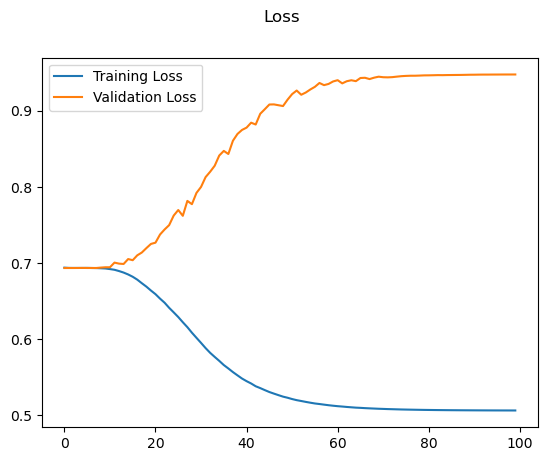

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plt.plot(training_record.history["loss"], label="Training Loss")
plt.plot(training_record.history["val_loss"], label="Validation Loss")
plt.legend()
fig.suptitle("Loss")
plt.show()